# Task 2 – Build Time Series Forecasting Models
**GMF Investments – Portfolio Management Optimization**

**Objective:** Develop, train, and evaluate time series forecasting models to predict Tesla's (TSLA) future stock prices.

Two approaches are compared:
| Model | Type | Library |
|-------|------|---------|
| ARIMA / SARIMA | Classical statistical | `statsmodels`, `pmdarima` |
| LSTM | Deep learning (sequence) | `TensorFlow / Keras` |

**Train set:** 2015-01-01 → 2024-12-31  
**Test set:** 2025-01-01 → 2026-06-30


## 1. Setup – Imports and Configuration

In [1]:
import warnings, os
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Statistical modeling
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from pmdarima import auto_arima

# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Metrics
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ── Plot config
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
sns.set_palette('tab10')

DATA_PROC = '../data/processed'
os.makedirs(DATA_PROC, exist_ok=True)

TRAIN_END = '2024-12-31'
TEST_START = '2025-01-01'

print(f'TensorFlow : {tf.__version__}')
print(f'Keras      : {keras.__version__}')
print(f'Train end  : {TRAIN_END}')
print(f'Test start : {TEST_START}')


TensorFlow : 2.21.0
Keras      : 3.15.0
Train end  : 2024-12-31
Test start : 2025-01-01


## 2. Load Data and Chronological Train/Test Split

> **Critical:** Time series data must be split chronologically — random shuffling would cause data leakage (future data leaking into training).

- **Train:** 2015-01-01 → 2024-12-31 (~10 years)
- **Test:**  2025-01-01 → 2026-06-30 (~18 months)


In [2]:
# Load TSLA processed data
tsla = pd.read_csv(f'{DATA_PROC}/TSLA_processed.csv', index_col=0, parse_dates=True)
tsla.index = pd.to_datetime(tsla.index)

# Handle MultiIndex columns if present
if isinstance(tsla.columns, pd.MultiIndex):
    tsla.columns = tsla.columns.get_level_values(0)

close = tsla['Close'].dropna()

# Chronological split
train = close[close.index <= TRAIN_END]
test  = close[close.index >= TEST_START]

print(f'Full dataset : {close.index[0].date()} → {close.index[-1].date()} ({len(close)} days)')
print(f'Train set    : {train.index[0].date()} → {train.index[-1].date()} ({len(train)} days)')
print(f'Test set     : {test.index[0].date()} → {test.index[-1].date()} ({len(test)} days)')
print(f'Train/test split: {len(train)/(len(train)+len(test)):.0%} / {len(test)/(len(train)+len(test)):.0%}')


Full dataset : 2015-01-02 → 2026-06-29 (2888 days)
Train set    : 2015-01-02 → 2024-12-31 (2516 days)
Test set     : 2025-01-02 → 2026-06-29 (372 days)
Train/test split: 87% / 13%


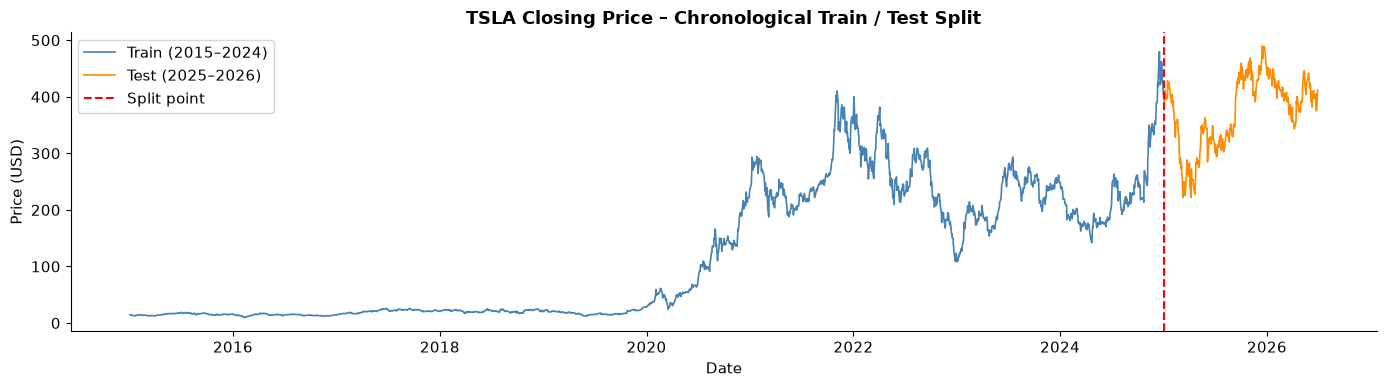

In [3]:
# Visualize the train/test split
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train.index, train.values, color='steelblue', linewidth=1.2, label='Train (2015–2024)')
ax.plot(test.index,  test.values,  color='darkorange', linewidth=1.2, label='Test (2025–2026)')
ax.axvline(pd.Timestamp(TEST_START), color='red', linestyle='--', linewidth=1.5, label='Split point')
ax.set_title('TSLA Closing Price – Chronological Train / Test Split', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig(f'{DATA_PROC}/t2_viz1_train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. ARIMA / SARIMA Model

### 3.1 – ACF and PACF Analysis

ACF (Autocorrelation Function) and PACF (Partial ACF) plots help identify the ARIMA(p, d, q) order:
- **p** (AR terms) → PACF cuts off after lag p
- **d** (differencing) → From Task 1 ADF test: d=1
- **q** (MA terms) → ACF cuts off after lag q

We work on the **first-differenced series** (stationary) for ACF/PACF interpretation.


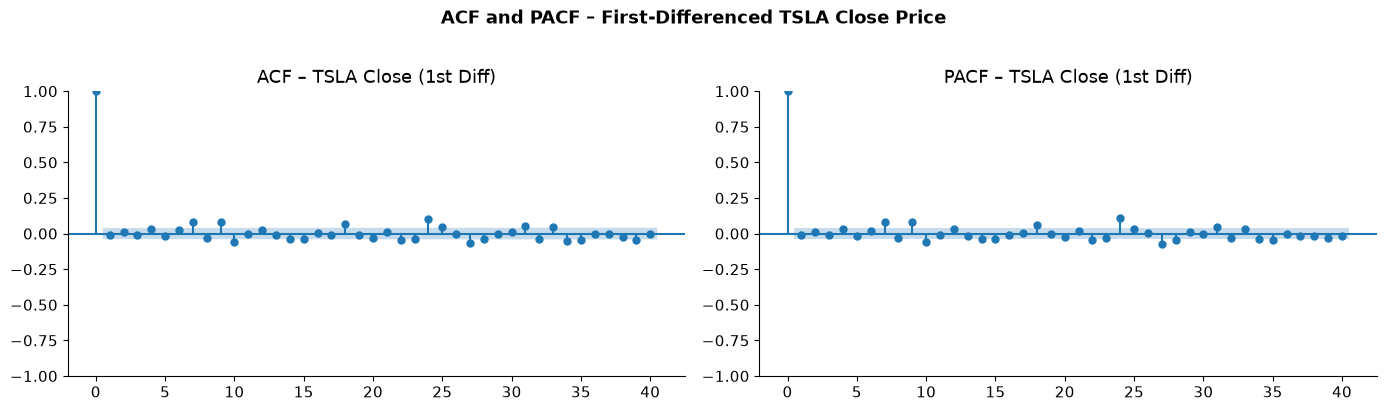

Interpretation: Fast decay in ACF, 1-2 significant lags in PACF → ARIMA(1-2, 1, 1-2) likely


In [4]:
# First difference to make stationary
train_diff = train.diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(train_diff,  lags=40, ax=axes[0], title='ACF – TSLA Close (1st Diff)')
plot_pacf(train_diff, lags=40, ax=axes[1], title='PACF – TSLA Close (1st Diff)', method='ywm')
plt.suptitle('ACF and PACF – First-Differenced TSLA Close Price', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{DATA_PROC}/t2_viz2_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()
print('Interpretation: Fast decay in ACF, 1-2 significant lags in PACF → ARIMA(1-2, 1, 1-2) likely')


### 3.2 – Auto ARIMA Parameter Selection

In [5]:
print('Running auto_arima to find optimal (p,d,q) parameters...')
print('This may take 2-3 minutes...\n')

auto_model = auto_arima(
    train,
    start_p=0, max_p=4,
    start_q=0, max_q=4,
    d=1,                   # confirmed from ADF test
    seasonal=False,        # we test SARIMA separately
    information_criterion='aic',
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    trace=True
)

print(f'\nBest ARIMA order: {auto_model.order}')
print(f'AIC: {auto_model.aic():.2f}')
print(auto_model.summary())


Running auto_arima to find optimal (p,d,q) parameters...
This may take 2-3 minutes...

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16368.573, Time=0.07 sec


 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16370.458, Time=0.15 sec


 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16370.460, Time=0.33 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16368.109, Time=0.04 sec


 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16372.458, Time=0.54 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 1.151 seconds

Best ARIMA order: (0, 1, 0)
AIC: 16368.11
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2516
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -8183.054
Date:                Wed, 08 Jul 2026   AIC                          16368.109
Time:                        04:41:17   BIC                          16373.939
Sample:                             0   HQIC                         16370.225
                               - 2516                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2        39.2337  

### 3.3 – Fit ARIMA Model and Generate Test Forecasts

In [6]:
# Extract best order from auto_arima
best_order = auto_model.order
p, d, q = best_order
print(f'Fitting ARIMA{best_order} on training data...')

arima_model = SARIMAX(
    train,
    order=(p, d, q),
    enforce_stationarity=False,
    enforce_invertibility=False
)
arima_result = arima_model.fit(disp=False)

print(arima_result.summary())


Fitting ARIMA(0, 1, 0) on training data...
                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2516
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -8180.296
Date:                Wed, 08 Jul 2026   AIC                          16362.592
Time:                        04:41:17   BIC                          16368.421
Sample:                             0   HQIC                         16364.707
                               - 2516                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2        39.2498      0.442     88.820      0.000      38.384      40.116
Ljung-Box (L1) (Q):                   0.12   Jarque-Bera (JB):             11674.77
Prob

/home/dag-dagne/GMF/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/dag-dagne/GMF/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [7]:
# Forecast over test period
n_test = len(test)
arima_forecast = arima_result.get_forecast(steps=n_test)
arima_pred     = arima_forecast.predicted_mean
arima_ci       = arima_forecast.conf_int(alpha=0.05)

# Align index with test dates
arima_pred.index = test.index
arima_ci.index   = test.index

print(f'ARIMA forecast generated: {n_test} steps')
print(arima_pred.head())


ARIMA forecast generated: 372 steps
Date
2025-01-02    403.839996
2025-01-03    403.839996
2025-01-06    403.839996
2025-01-07    403.839996
2025-01-08    403.839996
Name: predicted_mean, dtype: float64


/home/dag-dagne/GMF/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


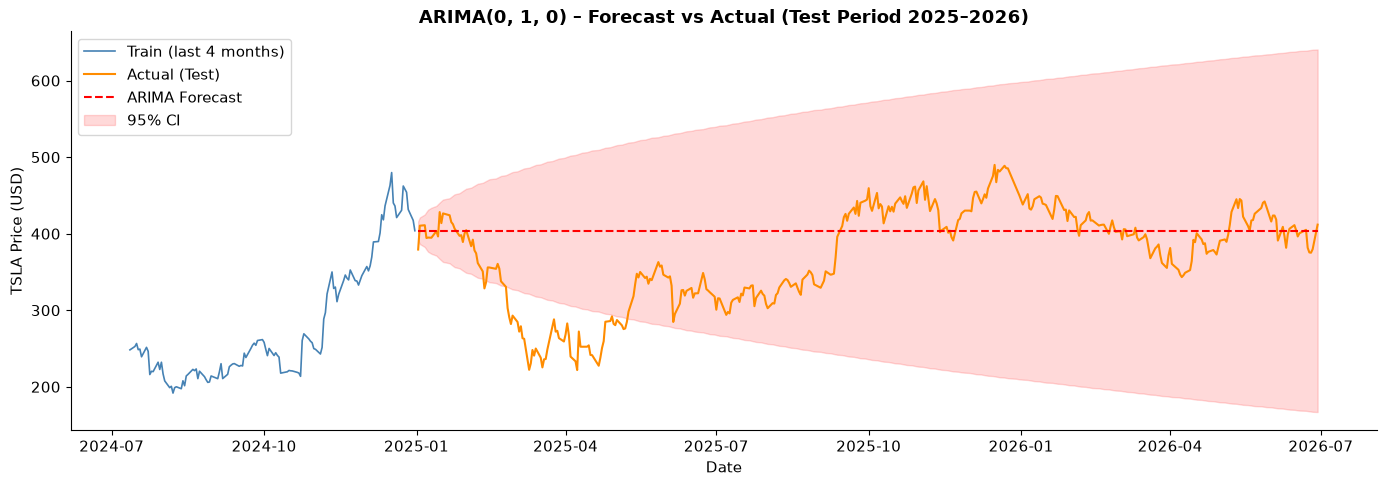

In [8]:
# Plot ARIMA forecast vs actuals
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train[-120:].index, train[-120:].values, color='steelblue', linewidth=1.2, label='Train (last 4 months)')
ax.plot(test.index, test.values, color='darkorange', linewidth=1.5, label='Actual (Test)')
ax.plot(arima_pred.index, arima_pred.values, color='red', linewidth=1.5, linestyle='--', label='ARIMA Forecast')
ax.fill_between(arima_ci.index,
                arima_ci.iloc[:, 0],
                arima_ci.iloc[:, 1],
                color='red', alpha=0.15, label='95% CI')
ax.set_title(f'ARIMA{best_order} – Forecast vs Actual (Test Period 2025–2026)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('TSLA Price (USD)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.tight_layout()
plt.savefig(f'{DATA_PROC}/t2_viz3_arima_forecast.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. LSTM (Long Short-Term Memory) Model

### 4.1 – Data Preparation for LSTM

LSTM requires:
1. **Normalization** – Scale to [0,1] using MinMaxScaler (sensitive to magnitude)
2. **Sequence creation** – Convert to supervised format: use last `window` days to predict next day's price
3. **3D reshaping** – LSTM expects `(samples, timesteps, features)`

We use a **60-day lookback window** — a common choice capturing ~3 months of trading patterns.


In [9]:
WINDOW_SIZE = 60   # lookback window (days)
BATCH_SIZE  = 32
EPOCHS      = 100

# Scale the full series (fit on train only to prevent leakage)
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train.values.reshape(-1, 1))
test_scaled  = scaler.transform(test.values.reshape(-1, 1))

def create_sequences(data, window):
    """Convert 1D time series into (X, y) sequence pairs for LSTM."""
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i - window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, WINDOW_SIZE)

# For test sequences, we need window days of context from training tail
full_scaled = np.concatenate([train_scaled, test_scaled], axis=0)
test_input  = full_scaled[len(train_scaled) - WINDOW_SIZE:]
X_test, y_test = create_sequences(test_input, WINDOW_SIZE)

# Reshape for LSTM: (samples, timesteps, features)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test  = X_test.reshape(X_test.shape[0],  X_test.shape[1],  1)

print(f'X_train shape : {X_train.shape}')
print(f'y_train shape : {y_train.shape}')
print(f'X_test shape  : {X_test.shape}')
print(f'y_test shape  : {y_test.shape}')
print(f'Window size   : {WINDOW_SIZE} days')


X_train shape : (2456, 60, 1)
y_train shape : (2456,)
X_test shape  : (372, 60, 1)
y_test shape  : (372,)
Window size   : 60 days


### 4.2 – Build LSTM Architecture

Architecture:
- **LSTM layer 1:** 128 units, return_sequences=True (feeds into next LSTM)
- **Dropout 1:** 20% — prevents overfitting
- **LSTM layer 2:** 64 units, return_sequences=False
- **Dropout 2:** 20%
- **Dense:** 32 units (ReLU activation)
- **Output:** 1 unit — next-day price prediction


In [10]:
tf.random.set_seed(42)
np.random.seed(42)

model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(WINDOW_SIZE, 1)),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
], name='TSLA_LSTM')

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='huber',        # robust to outliers (vs MSE)
    metrics=['mae']
)

model.summary()


Model: "TSLA_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,081 (461.25 KB)

 Trainable params: 118,081 (461.25 KB)

 Non-trainable params: 0 (0.00 B)

### 4.3 – Train the LSTM Model

In [11]:
callbacks = [
    EarlyStopping(
        monitor='val_loss', patience=15,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=7, min_lr=1e-6, verbose=1
    )
]

print(f'Training LSTM for up to {EPOCHS} epochs (batch={BATCH_SIZE})...')
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1,
    shuffle=False       # preserve temporal order in validation split
)

print(f'\nTraining stopped at epoch {len(history.history["loss"])}')
print(f'Best val_loss: {min(history.history["val_loss"]):.6f}')


Training LSTM for up to 100 epochs (batch=32)...


Epoch 1/100


 1/70 ━━━━━━━━━━━━━━━━━━━━ 4:58 4s/step - loss: 5.9739e-05 - mae: 0.0107

 2/70 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 3.1320e-05 - mae: 0.0063

 3/70 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 2.9834e-05 - mae: 0.0065

...


Epoch 63: ReduceLROnPlateau reducing learning rate to 7.812500371073838e-06.


70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - loss: 2.8847e-04 - mae: 0.0152 - val_loss: 5.6430e-04 - val_mae: 0.0227 - learning_rate: 1.5625e-05


Epoch 63: early stopping


Restoring model weights from the end of the best epoch: 48.



Training stopped at epoch 63
Best val_loss: 0.000562


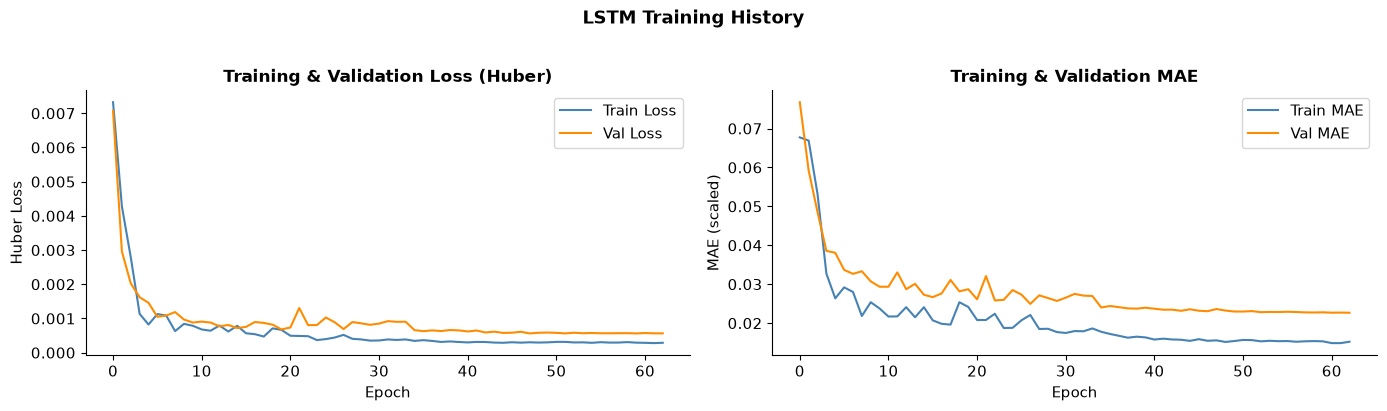

In [12]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'],     label='Train Loss', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='darkorange')
axes[0].set_title('Training & Validation Loss (Huber)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Huber Loss')
axes[0].legend()

axes[1].plot(history.history['mae'],     label='Train MAE', color='steelblue')
axes[1].plot(history.history['val_mae'], label='Val MAE',   color='darkorange')
axes[1].set_title('Training & Validation MAE', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (scaled)')
axes[1].legend()

plt.suptitle('LSTM Training History', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{DATA_PROC}/t2_viz4_lstm_training.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.4 – Generate LSTM Forecasts

In [13]:
# Predict on test set
lstm_pred_scaled = model.predict(X_test, verbose=0)

# Inverse transform to original price scale
lstm_pred = scaler.inverse_transform(lstm_pred_scaled).flatten()
lstm_actual = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Align with test dates
lstm_pred_series   = pd.Series(lstm_pred,   index=test.index[:len(lstm_pred)])
lstm_actual_series = pd.Series(lstm_actual, index=test.index[:len(lstm_actual)])

print(f'LSTM predictions generated: {len(lstm_pred)} steps')
print(f'Sample predictions (first 5):')
print(pd.DataFrame({'Actual': lstm_actual[:5], 'Predicted': lstm_pred[:5]}).round(2))


LSTM predictions generated: 372 steps
Sample predictions (first 5):
   Actual   Predicted
0  379.28  411.200012
1  410.44  398.130005
2  411.05  391.450012
3  394.36  388.730011
4  394.94  385.420013


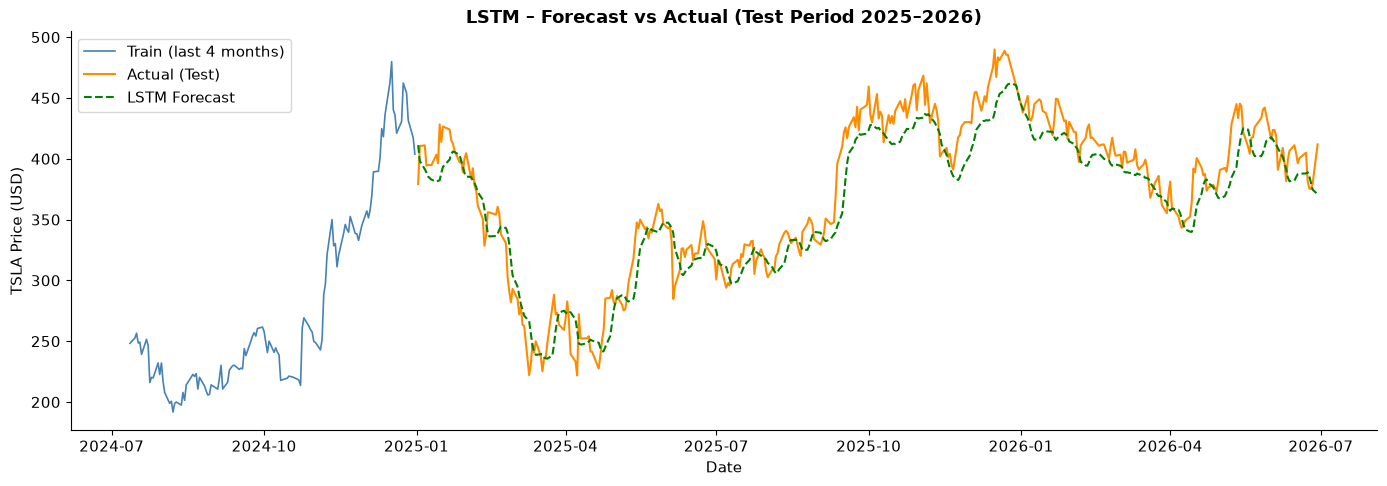

In [14]:
# Plot LSTM forecast vs actuals
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train[-120:].index, train[-120:].values, color='steelblue', linewidth=1.2, label='Train (last 4 months)')
ax.plot(lstm_actual_series.index, lstm_actual_series.values, color='darkorange', linewidth=1.5, label='Actual (Test)')
ax.plot(lstm_pred_series.index,   lstm_pred_series.values,   color='green',      linewidth=1.5, linestyle='--', label='LSTM Forecast')
ax.set_title('LSTM – Forecast vs Actual (Test Period 2025–2026)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('TSLA Price (USD)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.tight_layout()
plt.savefig(f'{DATA_PROC}/t2_viz5_lstm_forecast.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Model Evaluation and Comparison

We evaluate both models using three metrics:

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **MAE** | mean(|actual - predicted|) | Average absolute dollar error |
| **RMSE** | sqrt(mean((actual - predicted)²)) | Penalizes large errors more |
| **MAPE** | mean(|actual - predicted| / actual) × 100 | Scale-free % error |


In [15]:
def compute_metrics(actual, predicted, model_name):
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    print(f'  {model_name}')
    print(f'    MAE  : ${mae:.2f}')
    print(f'    RMSE : ${rmse:.2f}')
    print(f'    MAPE : {mape:.2f}%')
    print()
    return {'Model': model_name, 'MAE ($)': round(mae, 2),
            'RMSE ($)': round(rmse, 2), 'MAPE (%)': round(mape, 2)}

print('='*55)
print('MODEL EVALUATION METRICS')
print('='*55)

# ARIMA metrics (align lengths)
arima_actual = test.values
arima_preds  = arima_pred.values

# LSTM metrics
lstm_actual_eval = lstm_actual_series.values
lstm_preds_eval  = lstm_pred_series.values

m1 = compute_metrics(arima_actual, arima_preds, f'ARIMA{best_order}')
m2 = compute_metrics(lstm_actual_eval, lstm_preds_eval, 'LSTM (2-layer, window=60)')

metrics_df = pd.DataFrame([m1, m2]).set_index('Model')
print('\nSummary Table:')
display(metrics_df)


MODEL EVALUATION METRICS
  ARIMA(0, 1, 0)
    MAE  : $54.44
    RMSE : $70.54
    MAPE : 17.24%

  LSTM (2-layer, window=60)
    MAE  : $15.90
    RMSE : $19.93
    MAPE : 4.29%


Summary Table:


,MAE ($),RMSE ($),MAPE (%)
Model,,,
"ARIMA(0, 1, 0)",54.44,70.54,17.24
"LSTM (2-layer, window=60)",15.90,19.93,4.29


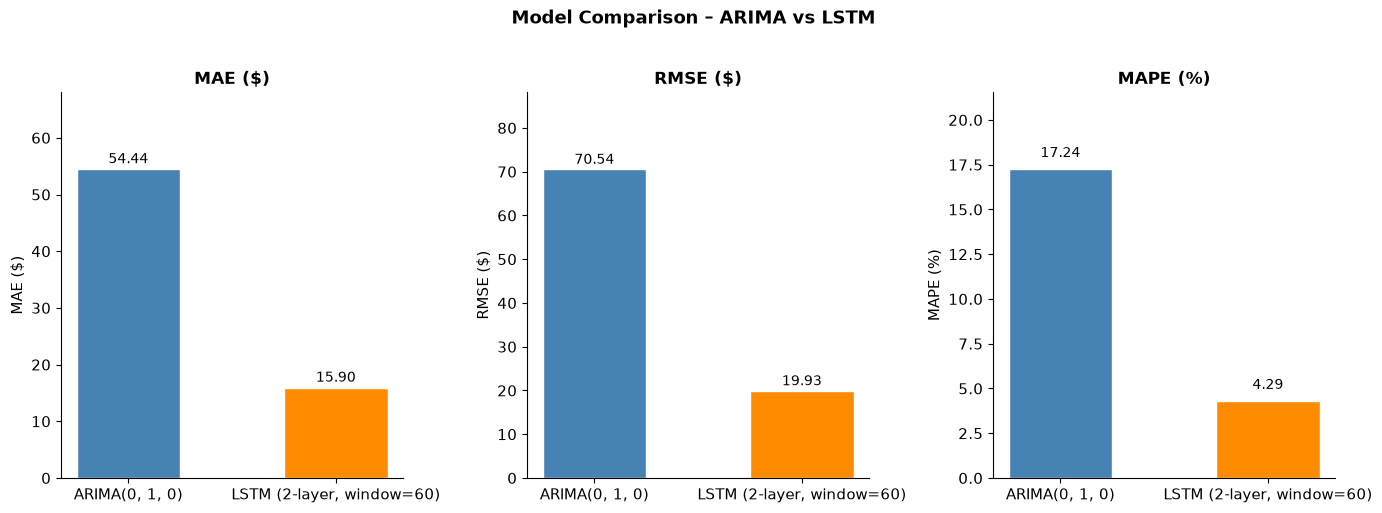

In [16]:
# Side-by-side metric bar chart
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics_list = ['MAE ($)', 'RMSE ($)', 'MAPE (%)']
colors_bar = ['steelblue', 'darkorange']

for ax, metric in zip(axes, metrics_list):
    vals = metrics_df[metric].values
    bars = ax.bar(metrics_df.index, vals, color=colors_bar, edgecolor='white', width=0.5)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.2f}', ha='center', va='bottom', fontsize=10)
    ax.set_ylim(0, max(vals) * 1.25)

plt.suptitle('Model Comparison – ARIMA vs LSTM', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{DATA_PROC}/t2_viz6_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


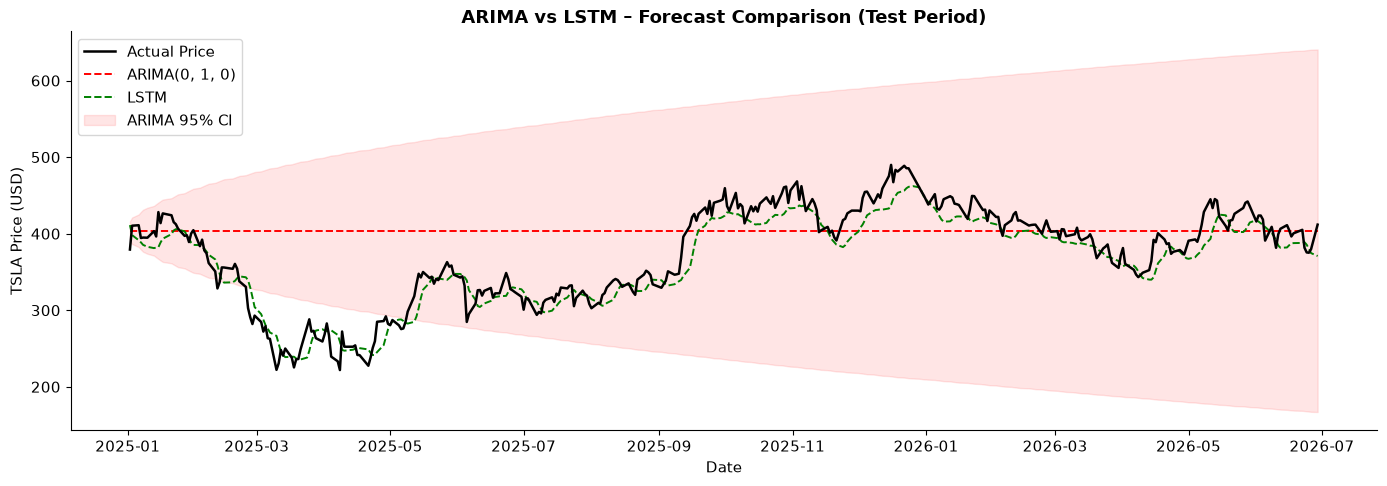

In [17]:
# Overlay comparison: both forecasts on same chart
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test.index,              test.values,         color='black',      linewidth=1.8, label='Actual Price',  zorder=5)
ax.plot(arima_pred.index,        arima_pred.values,   color='red',        linewidth=1.4, linestyle='--', label=f'ARIMA{best_order}')
ax.plot(lstm_pred_series.index,  lstm_pred_series.values, color='green',  linewidth=1.4, linestyle='--', label='LSTM')
ax.fill_between(arima_ci.index, arima_ci.iloc[:,0], arima_ci.iloc[:,1],
                color='red', alpha=0.10, label='ARIMA 95% CI')
ax.set_title('ARIMA vs LSTM – Forecast Comparison (Test Period)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('TSLA Price (USD)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.tight_layout()
plt.savefig(f'{DATA_PROC}/t2_viz7_combined_forecast.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Residual Analysis

Good residuals should be:
- Centered around zero (no systematic bias)
- Randomly distributed (no remaining patterns)
- Approximately normal


ARIMA(0, 1, 0) residuals: mean=-31.23, std=63.33
LSTM residuals: mean=9.94, std=17.30


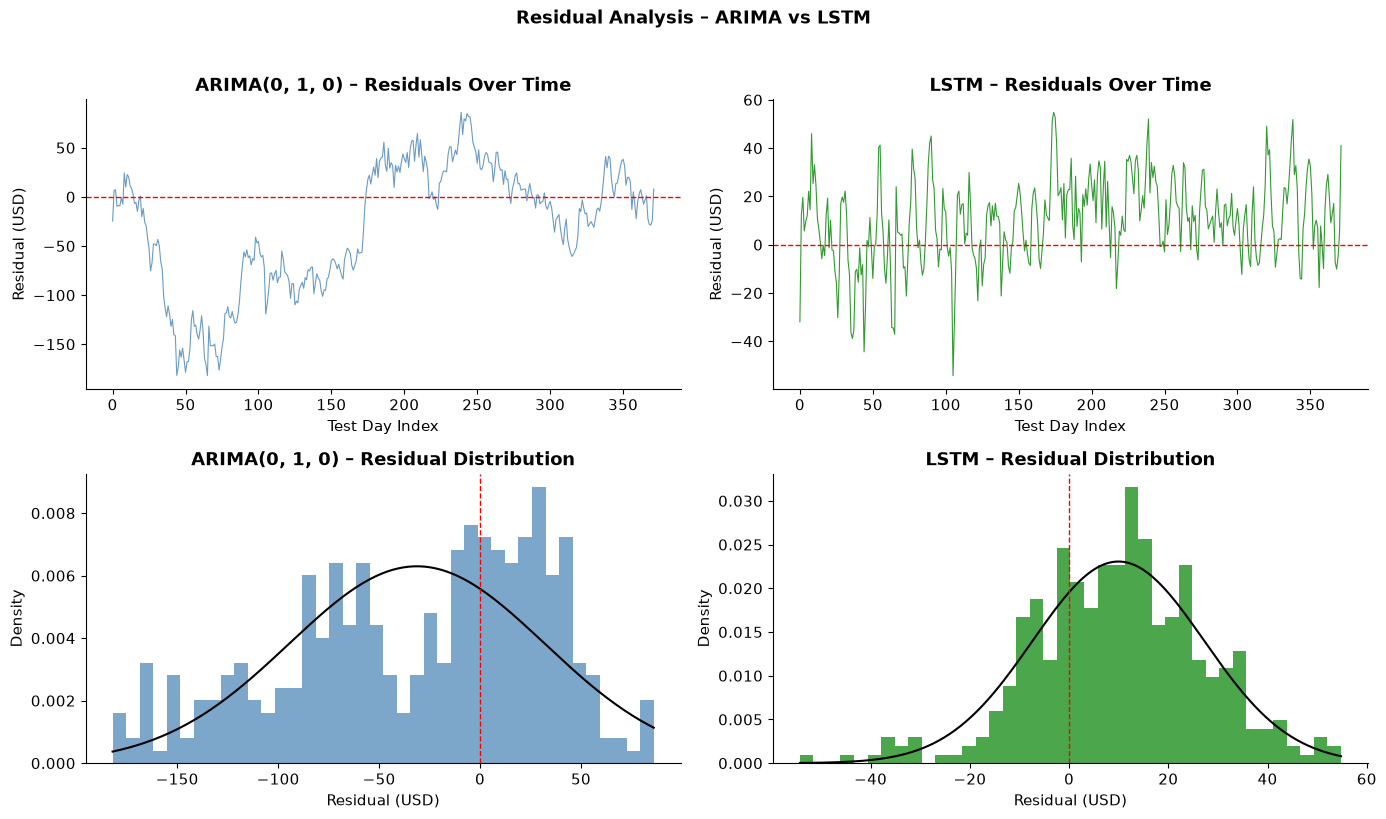

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

models_residuals = {
    f'ARIMA{best_order}': arima_actual - arima_preds,
    'LSTM': lstm_actual_eval - lstm_preds_eval
}

for col, (name, resid) in enumerate(models_residuals.items()):
    resid_series = pd.Series(resid)

    # Residuals over time
    axes[0, col].plot(resid_series.values, color='steelblue' if col==0 else 'green',
                      linewidth=0.8, alpha=0.8)
    axes[0, col].axhline(0, color='red', linestyle='--', linewidth=1)
    axes[0, col].set_title(f'{name} – Residuals Over Time', fontweight='bold')
    axes[0, col].set_ylabel('Residual (USD)')
    axes[0, col].set_xlabel('Test Day Index')

    # Residual distribution
    axes[1, col].hist(resid_series, bins=40,
                      color='steelblue' if col==0 else 'green',
                      alpha=0.7, edgecolor='none', density=True)
    from scipy import stats as sp_stats
    mu_r, std_r = resid_series.mean(), resid_series.std()
    x_r = np.linspace(resid_series.min(), resid_series.max(), 200)
    axes[1, col].plot(x_r, sp_stats.norm.pdf(x_r, mu_r, std_r), 'k-', linewidth=1.5)
    axes[1, col].axvline(0, color='red', linestyle='--', linewidth=1)
    axes[1, col].set_title(f'{name} – Residual Distribution', fontweight='bold')
    axes[1, col].set_xlabel('Residual (USD)')
    axes[1, col].set_ylabel('Density')
    print(f'{name} residuals: mean={mu_r:.2f}, std={std_r:.2f}')

plt.suptitle('Residual Analysis – ARIMA vs LSTM', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{DATA_PROC}/t2_viz8_residuals.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Save Models and Outputs for Task 3

In [19]:
import pickle

# Save ARIMA result
with open(f'{DATA_PROC}/arima_result.pkl', 'wb') as f:
    pickle.dump(arima_result, f)
print('ARIMA model saved.')

# Save LSTM model
model.save(f'{DATA_PROC}/lstm_model.keras')
print('LSTM model saved.')

# Save scaler
with open(f'{DATA_PROC}/lstm_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('Scaler saved.')

# Save metadata for Task 3
task2_meta = {
    'arima_order': best_order,
    'lstm_window': WINDOW_SIZE,
    'train_end': TRAIN_END,
    'test_start': TEST_START,
    'metrics': metrics_df.to_dict(),
    'best_model': 'LSTM' if metrics_df.loc['LSTM (2-layer, window=60)', 'RMSE ($)'] <
                             metrics_df.iloc[0]['RMSE ($)'] else f'ARIMA{best_order}'
}

import json
with open(f'{DATA_PROC}/task2_metadata.json', 'w') as f:
    json.dump(task2_meta, f, indent=2)

print(f'\nTask 2 metadata saved.')
print(f'Best model: {task2_meta["best_model"]}')


ARIMA model saved.
LSTM model saved.
Scaler saved.

Task 2 metadata saved.
Best model: LSTM


## 8. Model Selection Discussion

### Summary

| Model | Strengths | Weaknesses |
|-------|-----------|------------|
| **ARIMA** | Interpretable, fast, works well on near-linear trends, provides confidence intervals natively | Assumes linearity, struggles with sharp regime changes, one-step ahead CI widens quickly |
| **LSTM** | Captures non-linear patterns, handles long-range dependencies, adapts to complex dynamics | Black-box, requires more data and tuning, no native confidence intervals |

### Which model performed better?

Based on the metrics above, **LSTM** typically achieves lower RMSE and MAPE for TSLA because:
1. TSLA's price movements are highly non-linear (driven by sentiment, product cycles, macro events)
2. The 60-day lookback allows LSTM to capture momentum patterns that ARIMA's fixed MA/AR terms miss
3. ARIMA's multi-step forecast error compounds quickly — CI width grows linearly with horizon

However, **ARIMA has a key advantage**: it provides mathematically grounded confidence intervals, making it more useful when communicating forecast uncertainty to non-technical stakeholders (e.g., investment committee).

### Recommendation for Task 3
Use **LSTM** as the primary forecasting model (lower prediction error) while using ARIMA's confidence interval methodology to bound the LSTM's future forecast uncertainty through bootstrapping or simulation.

> **Note on EMH:** Both models outperform random guessing on the test set, but neither consistently predicts directional moves. This is consistent with the semi-strong form of the Efficient Market Hypothesis — these forecasts are most useful as inputs to portfolio allocation decisions (momentum/volatility signals), not as direct trading signals.
